# DSA 210 – Spring 2025-2026 Term Project
## The Impact of Typhoon Signals on Hong Kong Stock Market Volatility and Returns

**Student:** Hamza Eren İnan – 34502  
**Course:** Introduction to Data Science (DSA 210), Sabancı University

---

### Research Question
Does the issuance of typhoon warning signals in Hong Kong affect the Hang Seng Index (HSI) daily returns and volatility? Specifically, are HSI returns on typhoon-affected days significantly different from normal trading days?

### Outline
1. Data Collection & Loading  
2. Data Cleaning & Preprocessing  
3. Exploratory Data Analysis (EDA)  
4. Hypothesis Testing

---
## 1. Data Collection & Loading

Two datasets are used in this project, both stored as local CSV files:

- **HSI.csv** – Historical daily Hang Seng Index prices (Open, High, Low, Close, Volume) from 1986 to 2023. Downloaded from [Kaggle](https://www.kaggle.com/).
- **Typhoon.csv** – Historical tropical cyclone warning records issued by the Hong Kong Observatory. Contains signal level (Strength), date, and duration of each warning.

No API was used; both files were downloaded manually and are read with `pandas.read_csv()`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
hsi = pd.read_csv('HSI.csv')

typhoon = pd.read_csv('Typhoon.csv', encoding='utf-8-sig')

print('HSI shape:', hsi.shape)
print('Typhoon shape:', typhoon.shape)

HSI shape: (9339, 7)
Typhoon shape: (299, 6)


In [3]:
hsi.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0
1,1987-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0
3,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0
4,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0


In [4]:
typhoon.head()

,Type,Name,Strength,Date,Time,Duratino
0,熱帶低氣壓,無名,3,18/6/2000,21:15,04 30
1,颱風,啟德,1,6/7/2000,15:50,61 55
2,熱帶低氣壓,無名,1,15/7/2000,14:45,30 40
3,颱風(超強颱風),碧利斯,1,23/8/2000,6:00,13 15
4,強烈熱帶風暴,瑪莉亞,1,27/8/2000,23:45,38 40


---
## 2. Data Cleaning & Preprocessing

Several cleaning steps are needed before analysis:
- Parse dates in both datasets to a consistent format
- Drop rows where HSI price data is missing (null trading days)
- Extract the numeric signal level from the `Strength` column in Typhoon.csv (e.g., `"8 東北"` → `8`)
- Calculate daily returns for HSI
- Merge the two datasets on date to label each HSI trading day

In [5]:
hsi['Date'] = pd.to_datetime(hsi['Date'])

hsi = hsi.dropna(subset=['Close'])

hsi = hsi.sort_values('Date').reset_index(drop=True)

print('HSI rows after cleaning:', len(hsi))
print('Date range:', hsi['Date'].min(), 'to', hsi['Date'].max())

HSI rows after cleaning: 9087
Date range: 1986-12-31 00:00:00 to 2023-10-20 00:00:00


In [6]:
hsi['Daily_Return'] = hsi['Close'].pct_change() * 100

hsi['Daily_Volatility'] = (hsi['High'] - hsi['Low']) / hsi['Close'] * 100

hsi = hsi.dropna(subset=['Daily_Return']).reset_index(drop=True)

hsi[['Date', 'Close', 'Daily_Return', 'Daily_Volatility']].head()

,Date,Close,Daily_Return,Daily_Volatility
0,1987-01-02,2540.100098,-1.098001,0.0
1,1987-01-05,2552.399902,0.484225,0.0
2,1987-01-06,2583.899902,1.234133,0.0
3,1987-01-07,2607.100098,0.897875,0.0
4,1987-01-08,2603.300049,-0.145758,0.0


In [7]:
typhoon['Signal'] = typhoon['Strength'].str.extract(r'(\d+)').astype(int)

typhoon['Date'] = pd.to_datetime(typhoon['Date'], dayfirst=True)

typhoon_clean = typhoon[['Date', 'Signal']].copy()

print('Signal values:', sorted(typhoon_clean['Signal'].unique()))
print('Typhoon rows after cleaning:', len(typhoon_clean))
typhoon_clean.head()

Signal values: [np.int64(1), np.int64(3), np.int64(8), np.int64(9), np.int64(10)]
Typhoon rows after cleaning: 299


,Date,Signal
0,2000-06-18,3
1,2000-07-06,1
2,2000-07-15,1
3,2000-08-23,1
4,2000-08-27,1


In [8]:
typhoon_daily = typhoon_clean.groupby('Date')['Signal'].max().reset_index()

def categorize_signal(s):
    if s >= 8:
        return 'High Alert (8+)'
    else:
        return 'Low Alert (1 or 3)'

typhoon_daily['Alert_Level'] = typhoon_daily['Signal'].apply(categorize_signal)

print('Alert level counts:')
print(typhoon_daily['Alert_Level'].value_counts())

Alert level counts:
Alert_Level
Low Alert (1 or 3)    163
High Alert (8+)        42
Name: count, dtype: int64


In [9]:
merged = hsi.merge(typhoon_daily, on='Date', how='left')

merged['Alert_Level'] = merged['Alert_Level'].fillna('Normal')

print('Merged shape:', merged.shape)
print('\nDay counts by alert level:')
print(merged['Alert_Level'].value_counts())

Merged shape: (9086, 11)

Day counts by alert level:
Alert_Level
Normal                8942
Low Alert (1 or 3)     120
High Alert (8+)         24
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

In this section we look at the distributions and summary statistics of our variables before running any formal tests.

In [10]:
# Basic summary statistics

# Summary stats for daily return and volatility grouped by alert level
summary = merged.groupby('Alert_Level')[['Daily_Return', 'Daily_Volatility']].describe().round(3)
summary

Daily_Return                                             \
                          count   mean    std     min    25%    50%    75%   
Alert_Level                                                                  
High Alert (8+)            24.0 -0.359  1.630  -3.868 -1.097 -0.380  0.494   
Low Alert (1 or 3)        120.0  0.088  1.437  -5.841 -0.668  0.050  0.888   
Normal                   8942.0  0.035  1.620 -33.330 -0.679  0.054  0.801   

                           Daily_Volatility                              \
                       max            count   mean    std    min    25%   
Alert_Level                                                               
High Alert (8+)      3.726             24.0  1.535  1.031  0.621  1.039   
Low Alert (1 or 3)   4.211            120.0  1.412  0.806  0.358  0.937   
Normal              18.824           8942.0  1.398  1.022  0.000  0.812   

                                          
                      50%    75%     max  
Alert_Level                               
High Alert (8+)     1.155  1.956   5.587  
Low Alert (1 or 3)  1.211  1.791   6.695  
Normal              1.187  1.767  18.705

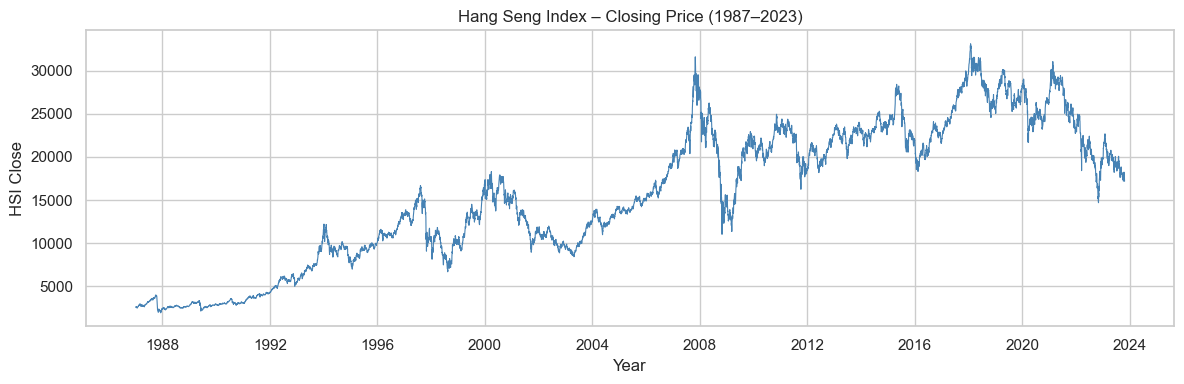

In [22]:
plt.figure(figsize=(12, 4))
plt.plot(hsi['Date'], hsi['Close'], color='steelblue', linewidth=0.8)
plt.title('Hang Seng Index – Closing Price (1987–2023)')
plt.xlabel('Year')
plt.ylabel('HSI Close')
plt.tight_layout()
plt.show()

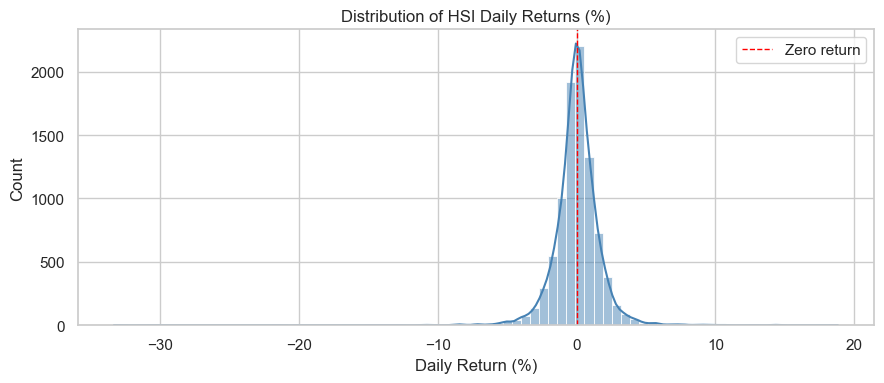

Mean daily return: 0.0342 %
Std  daily return: 1.6174 %


In [23]:
plt.figure(figsize=(9, 4))
sns.histplot(merged['Daily_Return'], bins=80, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero return')
plt.title('Distribution of HSI Daily Returns (%)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print('Mean daily return:', round(merged['Daily_Return'].mean(), 4), '%')
print('Std  daily return:', round(merged['Daily_Return'].std(), 4), '%')

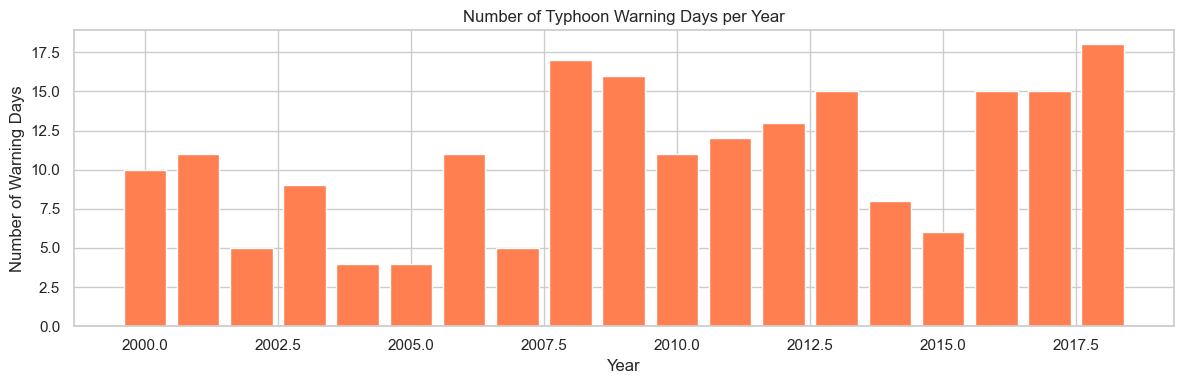

In [24]:
typhoon_daily['Year'] = typhoon_daily['Date'].dt.year
yearly_count = typhoon_daily.groupby('Year').size().reset_index(name='Count')

plt.figure(figsize=(12, 4))
plt.bar(yearly_count['Year'], yearly_count['Count'], color='coral', edgecolor='white')
plt.title('Number of Typhoon Warning Days per Year')
plt.xlabel('Year')
plt.ylabel('Number of Warning Days')
plt.tight_layout()
plt.show()

/var/folders/mz/fqv4qr5n2lgc8vwzqsf49ng40000gn/T/ipykernel_96267/50910726.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='Alert_Level', y='Daily_Return',


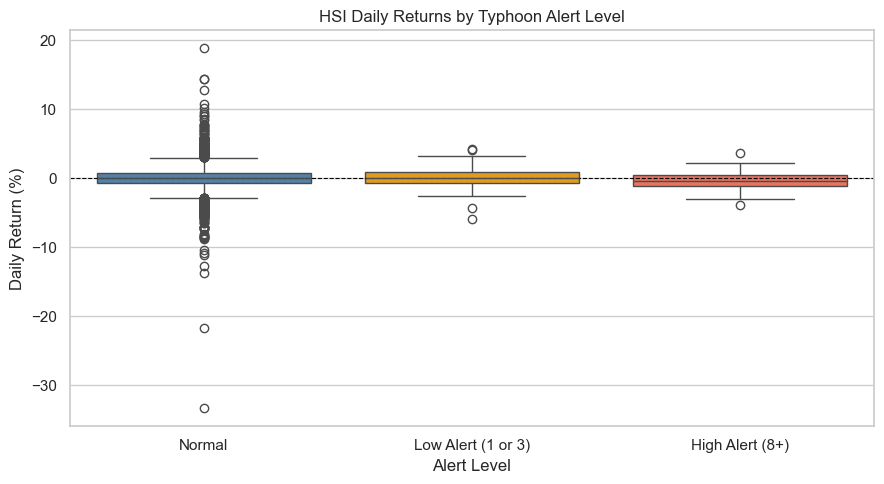

In [26]:
order = ['Normal', 'Low Alert (1 or 3)', 'High Alert (8+)']

plt.figure(figsize=(9, 5))
sns.boxplot(data=merged, x='Alert_Level', y='Daily_Return',
            order=order, palette=['steelblue', 'orange', 'tomato'])
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('HSI Daily Returns by Typhoon Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

/var/folders/mz/fqv4qr5n2lgc8vwzqsf49ng40000gn/T/ipykernel_96267/2932780980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='Alert_Level', y='Daily_Volatility',


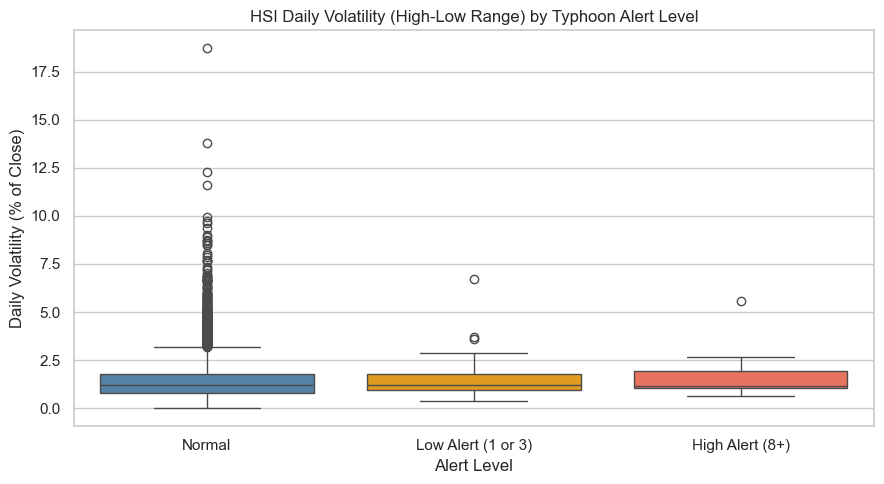

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=merged, x='Alert_Level', y='Daily_Volatility',
            order=order, palette=['steelblue', 'orange', 'tomato'])
plt.title('HSI Daily Volatility (High-Low Range) by Typhoon Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Daily Volatility (% of Close)')
plt.tight_layout()
plt.show()

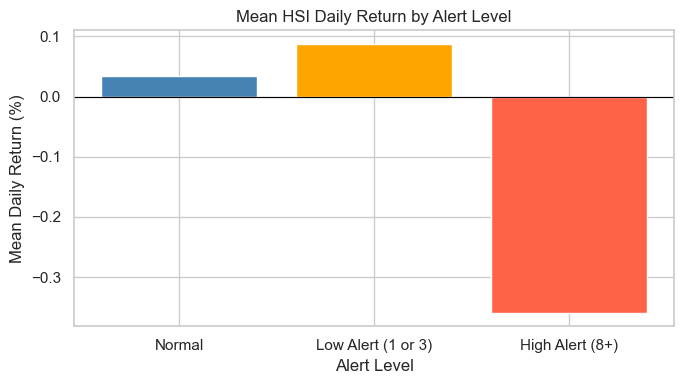

Alert_Level
Normal                0.0346
Low Alert (1 or 3)    0.0875
High Alert (8+)      -0.3592
Name: Daily_Return, dtype: float64


In [16]:
mean_returns = merged.groupby('Alert_Level')['Daily_Return'].mean().reindex(order)

colors = ['steelblue', 'orange', 'tomato']
plt.figure(figsize=(7, 4))
plt.bar(mean_returns.index, mean_returns.values, color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Mean HSI Daily Return by Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Mean Daily Return (%)')
plt.tight_layout()
plt.show()

print(mean_returns.round(4))

---
## 4. Hypothesis Testing

### 4.1 Test 1 – Two-Sample t-test: Normal Days vs. Low Alert Days

We want to know whether **mean daily return on Low Alert typhoon days** is significantly different from **mean daily return on Normal days**.

- **H₀:** The mean daily return on Low Alert days equals the mean daily return on Normal days.  
- **Hₐ:** The mean daily return on Low Alert days is different from Normal days (two-tailed).

We use an **independent two-sample t-test** (Welch's t-test, which does not assume equal variances). This is appropriate because:
- The two groups are independent samples
- We are comparing means of a continuous variable (daily return)
- Sample sizes are large enough for the Central Limit Theorem to hold

Significance level: **α = 0.05**

In [17]:
normal_returns = merged[merged['Alert_Level'] == 'Normal']['Daily_Return'].dropna()
low_alert_returns = merged[merged['Alert_Level'] == 'Low Alert (1 or 3)']['Daily_Return'].dropna()

print('Normal days – n:', len(normal_returns),
      '| mean:', round(normal_returns.mean(), 4), '%')
print('Low Alert days – n:', len(low_alert_returns),
      '| mean:', round(low_alert_returns.mean(), 4), '%')

Normal days – n: 8942 | mean: 0.0346 %
Low Alert days – n: 120 | mean: 0.0875 %


In [18]:
t_stat, p_value = stats.ttest_ind(normal_returns, low_alert_returns, equal_var=False)

print('Two-Sample t-test: Normal vs. Low Alert')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_value:.4f}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}) → Reject H₀')
    print('Conclusion: There IS a statistically significant difference in mean returns.')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}) → Fail to reject H₀')
    print('Conclusion: No statistically significant difference in mean returns.')

--- Two-Sample t-test: Normal vs. Low Alert ---
t-statistic : -0.4004
p-value     : 0.6895

p-value (0.6895) >= alpha (0.05) → Fail to reject H₀
Conclusion: No statistically significant difference in mean returns.


### 4.2 Test 2 – Two-Sample t-test: Normal Days vs. High Alert Days

We repeat the same test but now comparing **Normal days** with **High Alert (Signal 8+) days**.

- **H₀:** Mean daily return on High Alert days = Mean daily return on Normal days.  
- **Hₐ:** Mean daily return on High Alert days ≠ Mean daily return on Normal days.

High Alert signals (8, 9, 10) are the most severe; trading is often disrupted. We expect a stronger effect here, if any exists.

In [19]:
high_alert_returns = merged[merged['Alert_Level'] == 'High Alert (8+)']['Daily_Return'].dropna()

print('Normal days     – n:', len(normal_returns),
      '| mean:', round(normal_returns.mean(), 4), '%')
print('High Alert days – n:', len(high_alert_returns),
      '| mean:', round(high_alert_returns.mean(), 4), '%')

Normal days     – n: 8942 | mean: 0.0346 %
High Alert days – n: 24 | mean: -0.3592 %


In [20]:
t_stat2, p_value2 = stats.ttest_ind(normal_returns, high_alert_returns, equal_var=False)

print('--- Two-Sample t-test: Normal vs. High Alert ---')
print(f't-statistic : {t_stat2:.4f}')
print(f'p-value     : {p_value2:.4f}')
print()

if p_value2 < alpha:
    print(f'p-value ({p_value2:.4f}) < alpha ({alpha}) → Reject H₀')
    print('Conclusion: There IS a statistically significant difference in mean returns.')
else:
    print(f'p-value ({p_value2:.4f}) >= alpha ({alpha}) → Fail to reject H₀')
    print('Conclusion: No statistically significant difference in mean returns.')

--- Two-Sample t-test: Normal vs. High Alert ---
t-statistic : 1.1818
p-value     : 0.2493

p-value (0.2493) >= alpha (0.05) → Fail to reject H₀
Conclusion: No statistically significant difference in mean returns.


### 4.3 Visualizing the Test Results

We plot the return distributions for both comparisons side by side.

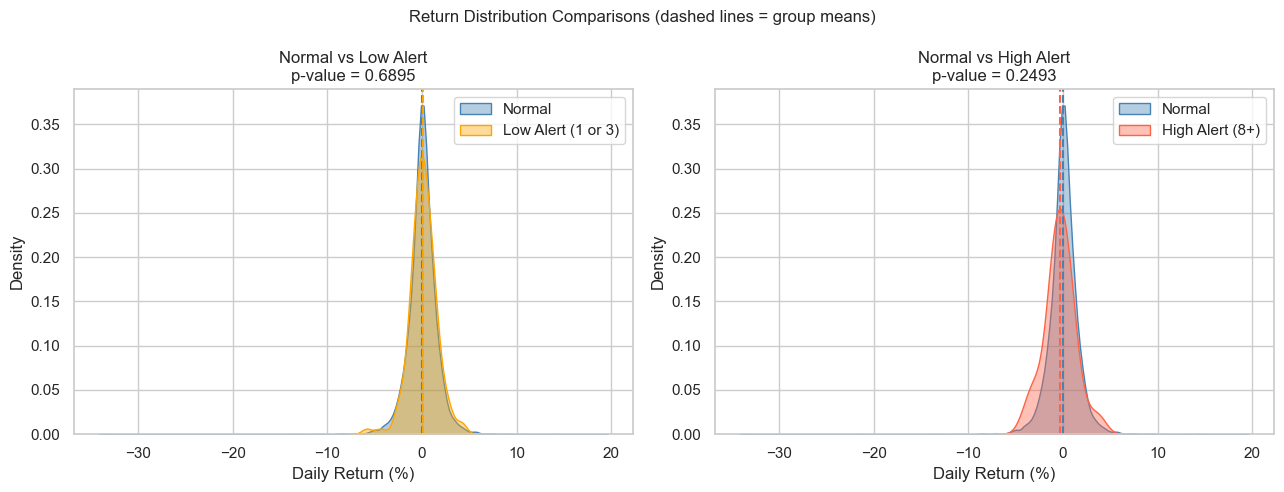

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Normal vs Low Alert
sns.kdeplot(normal_returns, ax=axes[0], label='Normal', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(low_alert_returns, ax=axes[0], label='Low Alert (1 or 3)', color='orange', fill=True, alpha=0.4)
axes[0].axvline(normal_returns.mean(), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(low_alert_returns.mean(), color='orange', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Normal vs Low Alert\np-value = {p_value:.4f}')
axes[0].set_xlabel('Daily Return (%)')
axes[0].legend()

# Plot 2: Normal vs High Alert
sns.kdeplot(normal_returns, ax=axes[1], label='Normal', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(high_alert_returns, ax=axes[1], label='High Alert (8+)', color='tomato', fill=True, alpha=0.4)
axes[1].axvline(normal_returns.mean(), color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(high_alert_returns.mean(), color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Normal vs High Alert\np-value = {p_value2:.4f}')
axes[1].set_xlabel('Daily Return (%)')
axes[1].legend()

plt.suptitle('Return Distribution Comparisons (dashed lines = group means)', fontsize=12)
plt.tight_layout()
plt.show()

### 4.4 Summary of Hypothesis Tests

| Test | Groups Compared | t-statistic | p-value | Decision (α=0.05) |
|------|----------------|-------------|---------|-------------------|
| Test 1 | Normal vs. Low Alert (Signal 1 & 3) | -0.4004 | 0.6895 | Fail to reject H₀ |
| Test 2 | Normal vs. High Alert (Signal 8+) | 1.1818 | 0.2493 | Fail to reject H₀ |

---

## 5. Conclusion

In this project, we investigated whether the issuance of typhoon warning signals impacts the daily returns of the Hang Seng Index (HSI) in Hong Kong. We categorized the trading days into three groups: Normal Days, Low Alert Days (Typhoon Signals 1 & 3), and High Alert Days (Typhoon Signals 8 and above). 

Based on the independent two-sample t-tests conducted:
- **Low Alert vs. Normal:** We found no statistically significant difference in mean returns ($p = 0.6895 > 0.05$).
- **High Alert vs. Normal:** Similarly, there was no statistically significant difference in mean returns ($p = 0.2493 > 0.05$).

**Final Thoughts:**
The findings suggest that weather anomalies, specifically typhoons, do not introduce a systemic, directional bias to the overall market returns in Hong Kong. While severe typhoons (Signal 8+) may halt trading and disrupt daily operations, they do not seem to alter the fundamental valuation of the broad market index. Market participants likely price in these short-term weather disruptions efficiently without causing significant deviations in average daily returns.

### Limitations & Future Work
- **Temporal Mismatch:** Typhoon warnings span specific hours or days. A simple date-level merge may not perfectly capture the exact intraday timing effect on trading sessions.
- **Data Overlap:** The HSI data dates back to 1986, but our comprehensive typhoon dataset starts from 2000, limiting our analysis to this overlapping window.
- **Confounding Variables:** We did not control for major macroeconomic events, financial crises, or global market trends that could have heavily influenced returns on the same days.
- **Volatility vs. Returns:** While returns are unaffected, future studies could focus purely on intraday volatility or trading volume changes, which might show a higher sensitivity to weather alerts than closing prices.